In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
MODELS    = CONFIGS['experiments']
SPLIT     = 'test'

MODELDICT = {'pod_bl':{'label':MODELS['pod']['runs']['pod_bl']['description'],'color':MODELS['pod']['runs']['pod_bl']['color'],'marker':'x'}}
for name,rc in MODELS['nn']['runs'].items():
    MODELDICT[name] = {'label':rc['description'],'color':rc['color'],'marker':'D'}
for name,rc in MODELS['sr']['optimizedeqs'].items():
    MODELDICT[name] = {'label':rc['description'],'color':rc['color'],'marker':'o'}

In [7]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for name in MODELDICT:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' in predtp.dims:
        predtp = predtp.mean('seed')
    if 'complexity' in predtp.dims:
        predtp = predtp.isel(complexity=0)
    ytrue,ypred   = xr.align(truetp,predtp,join='inner')
    results[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Loaded {len(results)}/{len(MODELDICT)} models!')

Loaded 9/9 models!


In [12]:
def exceedance_curve(arr,subsample=5):
    flat = arr.ravel()
    flat = flat[np.isfinite(flat)&(flat>0)]
    flat = np.sort(flat)[::-1][::subsample]
    prob = np.arange(1,len(flat)+1)/len(flat)
    return flat,prob
ytrueref = next(iter(results.values()))[0]
ytruevalues,ytrueprob = exceedance_curve(ytrueref.values)

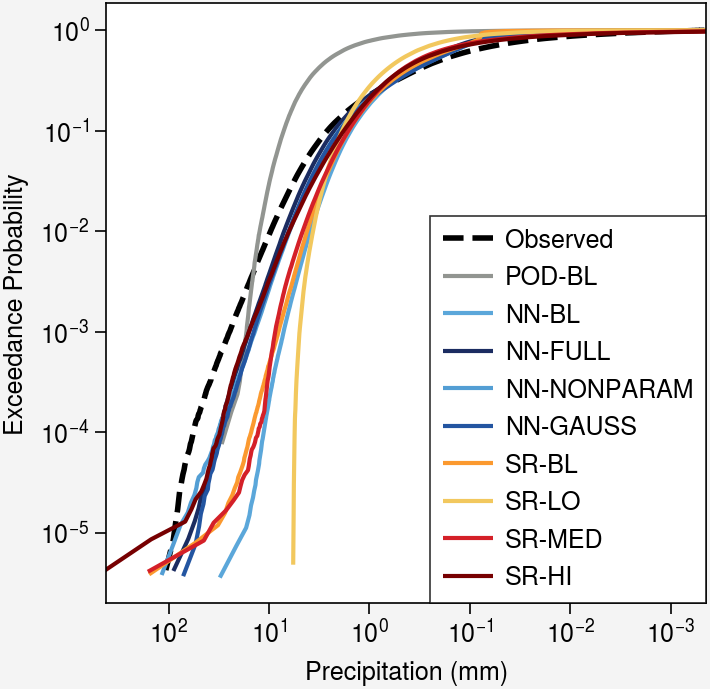

In [13]:
fig,ax = pplt.subplots(refwidth=3)
ax.plot(ytruevalues,ytrueprob,color='k',linestyle='--',linewidth=2,label='Observed',zorder=0)
for name,info in MODELDICT.items():
    if name not in results:
        continue
    ypredvalues,ypredprob = exceedance_curve(results[name][1].values)
    ax.plot(ypredvalues,ypredprob,color=info['color'],linewidth=1.5,label=info['label'])
ax.format(grid=False,xlabel='Precipitation (mm)',xscale='log',xformatter='log',
          ylabel='Exceedance Probability',yscale='log',yformatter='log')
ax.legend(loc='lr',ncols=1)
pplt.show()
fig.save('../figs/fig_4.jpg')

In [14]:
ytrueref = next(iter(results.values()))[0]
ytrue95  = ytrueref.quantile(0.95,dim='time',skipna=True)

ordered = [n for n in MODELDICT if n in results]
biases  = []
for name in ordered:
    _,ypred = results[name]
    ypred95 = ypred.quantile(0.95,dim='time',skipna=True)
    biases.append(ypred95-ytrue95)
vmax = max(float(abs(b).max()) for b in biases)

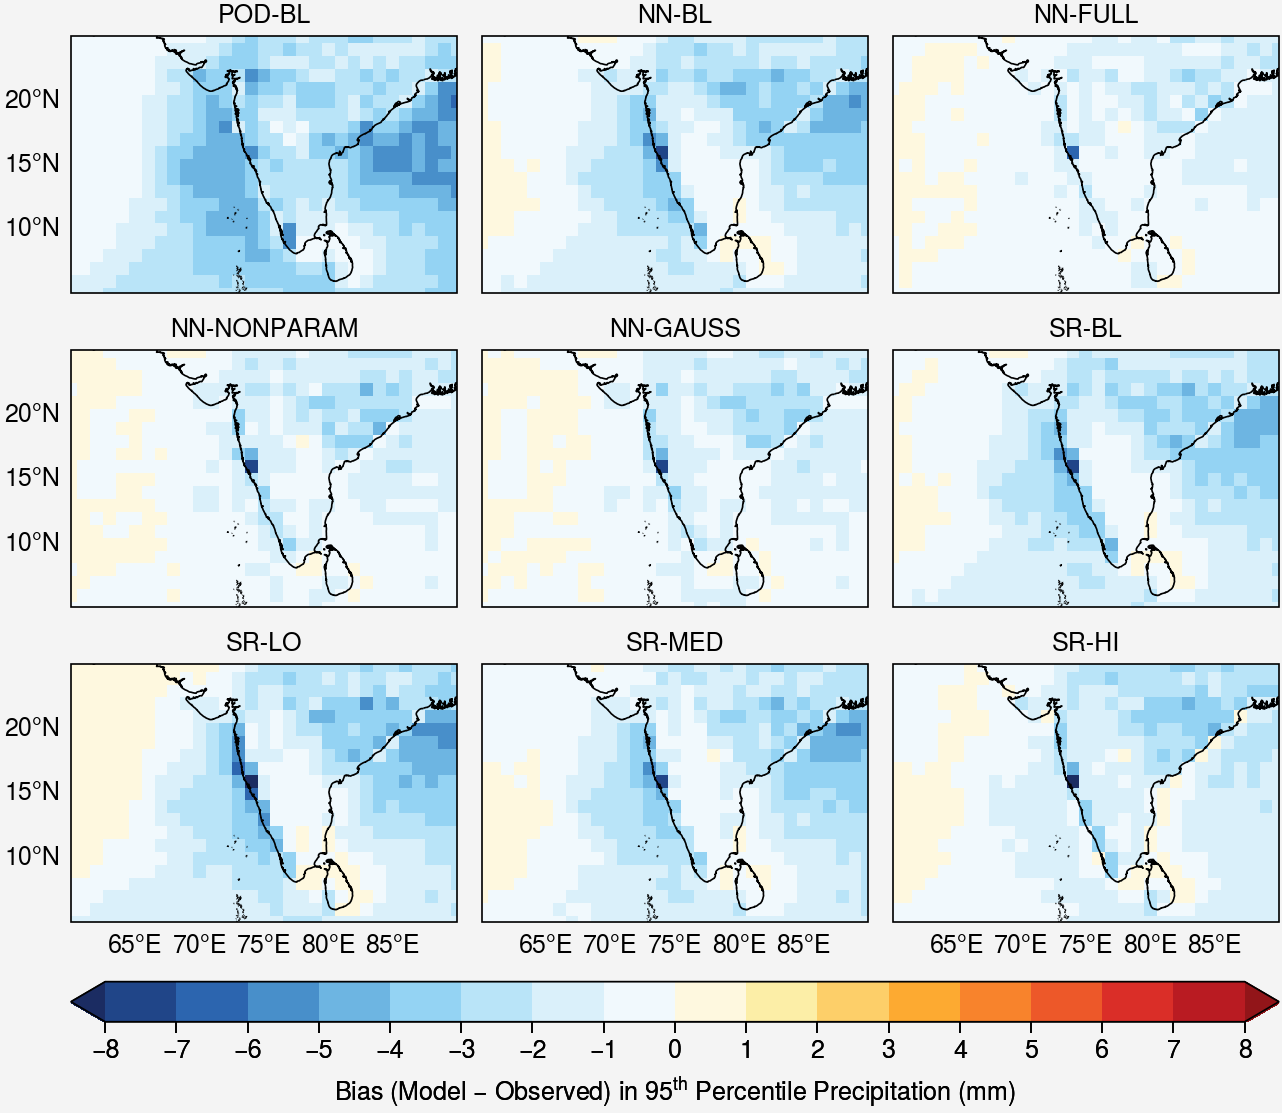

In [15]:
fig,axs = pplt.subplots(nrows=3,ncols=3,proj='cyl',figwidth=6.5,share=True)
axs.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,latlines=[10,15,20],lonlines=5,grid=False)
axs[-1,:].format(lonlabels='b')
axs[:,0].format(latlabels='l')
m = None
for ax,name,bias in zip(axs,ordered,biases):
    m = ax.pcolormesh(bias.lon,bias.lat,bias,cmap='ColdHot',vmin=-vmax,vmax=vmax,levels=21,extend='both')
    ax.format(title=MODELDICT[name]['label'])
fig.colorbar(m,loc='b',label='Bias (Model $-$ Observed) in 95$^{th}$ Percentile Precipitation (mm)',ticks=1)
pplt.show()
fig.save('../figs/fig_5.jpg')